In [2]:
import pathlib
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"

import torch
import trimesh
from metrics import chamfer_distance

import utils, dataset, visualization
from encoder import *
from decoder import *

%load_ext autoreload
%autoreload 2

/home/nikola/miniconda3/envs/adlr/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
device = torch.device('cuda:0')

In [5]:
#Load a model:

experiment_name = "Jun14_16-13_10_Objects_200epochs_32latent_enc64_dec128"
config, model_config, encoder, decoder = utils.reload_model(None, None, experiment_name, 'best_train', device)

trainset = dataset.Dataset_new('train', config['timesteps'])
# val = dataset.Dataset_new('val', config['timesteps'])
# test = dataset.Dataset_new('test', config['timesteps'])

print(trainset.real_length)

Loading train data: 100%|██████████| 10/10 [00:00<00:00, 618.03it/s]

10


In [9]:
generateDDIM = 1
generateDDPM = 0
number_of_points = 2048
DDIM_steps = 50
number_of_DDIM_iterations = 1
save = False
visualize = 1

set = trainset

# CRITICAL: Wrap the entire inference block to prevent VRAM explosion
with torch.no_grad():
    
    if generateDDIM:
        avg_chamfer = 0.
        for object_index in range(set.real_length):
            for i in range(number_of_DDIM_iterations):
                
                # Correctly extract the tensor, add batch dim, and push to GPU
                pc = set[object_index]['point_cloud'].to(device).unsqueeze(0)
                
                mean, log_variance = encoder(pc) 
                code = encoder.sample_latent_z(mean, log_variance)

                generated_pc_ddim = sample_ddim(
                    decoder, code, n_points=number_of_points, 
                    steps=DDIM_steps, timesteps=config['timesteps']
                )
                
                # Handle Chamfer output dynamically and extract the float (.item())
                chamfer_out = chamfer_distance(pc, generated_pc_ddim)
                dist = chamfer_out[0].item() if isinstance(chamfer_out, tuple) else chamfer_out.item()
                
                avg_chamfer += dist
                print(f"Chamfer distance, Object {object_index}: {dist:.4f}")
                
                if visualize:
                    visualization.visualize_comparison(pc, generated_pc_ddim, window_name="DDIM Target (Red) vs Generated (Blue)")
                
                if save:
                    # Only execute the Trimesh conversion if you are actually saving it
                    generated_pcd_ddim = trimesh.PointCloud(generated_pc_ddim.squeeze().cpu().numpy())
                    # Add your trimesh export logic here (e.g., generated_pcd_ddim.export("output.obj"))
                
        print(f"Average Chamfer distance = {avg_chamfer / (set.real_length * number_of_DDIM_iterations):.5f}")

    if generateDDPM:
        object_index = 0
        
        # Correctly extract the tensor, add batch dim, and push to GPU
        pc = set[object_index]['point_cloud'].to(device).unsqueeze(0)
        
        mean, log_variance = encoder(pc)
        code = encoder.sample_latent_z(mean, log_variance)
        
        generated_pc_ddpm = sample_ddpm(
            decoder, code, n_points=number_of_points, 
            timesteps=config['timesteps']
        )
        
        if visualize:
            visualization.visualize_comparison(pc, generated_pc_ddpm, window_name="DDPM Target (Red) vs Generated (Blue)")
            
        if save:
            generated_pcd_ddpm = trimesh.PointCloud(generated_pc_ddpm.squeeze().cpu().numpy())
            # Add your trimesh export logic here

Chamfer distance, Object 0: 0.0397
Chamfer distance, Object 1: 0.0166
Chamfer distance, Object 2: 0.0354
Chamfer distance, Object 3: 0.0533
Chamfer distance, Object 4: 0.0251
Chamfer distance, Object 5: 0.0118
Chamfer distance, Object 6: 0.0129
Chamfer distance, Object 7: 0.0143
Chamfer distance, Object 8: 0.1973
Chamfer distance, Object 9: 0.0208
Average Chamfer distance = 0.04272


Object 0: -0.019 ; [0.59, 0.76, 0.21, -0.38, -0.43, 1.23, 0.26, 1.01, -0.91, 0.71, 1.54, -1.96, -0.59, -0.72, 0.73, -0.26, 0.86, 0.16, -0.49, 1.7, 1.25, -0.92, -0.84, 0.09, 0.31, 1.25, -0.92, -1.17, -0.24, -1.8, -1.32, -0.33]
Object 1: -0.041 ; [0.61, -0.05, 0.79, -0.19, -0.39, 1.03, 0.38, 1.11, -1.01, 0.48, 1.26, -1.84, -0.57, -0.91, 0.72, -0.31, 1.3, 0.26, -0.84, 1.66, 1.38, -1.43, -0.74, 0.38, 0.69, 1.24, -0.86, -1.02, -0.75, -1.78, -1.55, -0.37]
Object 2: 0.202 ; [0.05, 0.32, 1.36, -0.26, -1.38, 1.45, 1.1, 1.56, -0.15, 0.82, 1.8, -1.12, -0.96, -0.06, 0.93, 1.8, 1.18, 0.04, 0.39, 1.38, 1.88, -0.47, -1.22, 0.83, 1.61, 0.64, -1.13, -0.35, -0.79, -2.0, -1.89, -0.89]
Object 3: -0.039 ; [0.66, 0.72, 0.65, -0.27, -0.77, 0.98, 0.15, 0.75, -0.77, 0.6, 1.37, -1.82, -0.96, -0.98, 1.22, -0.76, 1.09, 0.2, -0.15, 1.89, 1.26, -1.02, -1.06, 0.4, 0.7, 1.11, -0.91, -1.82, -0.22, -1.96, -1.17, -0.35]
Object 4: 0.110 ; [1.11, 1.34, -0.66, -0.82, 0.67, 1.97, 0.48, 1.22, -0.62, 1.97, 2.13, -1.28, -1.68,

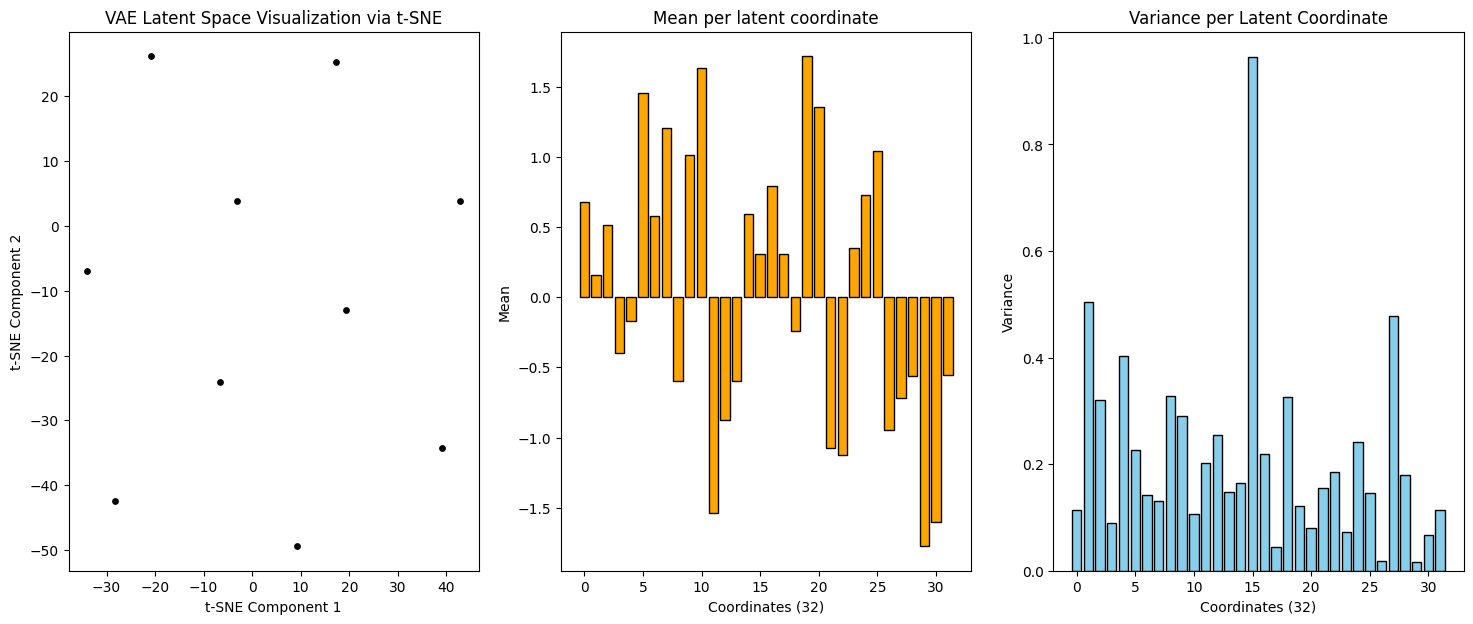

In [10]:
# VAE latent space visualization
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Extract latent representations
encoder.eval()
all_latents = []
all_labels = []
mean_matrix = torch.zeros([trainset.real_length, model_config['latent_dim']])

with torch.no_grad():
    for index in range(trainset.real_length):
        data = trainset[index]['point_cloud']
        data = data.to(device)
        mu, _ = encoder(data.unsqueeze(0)) 
        mu_list = mu.squeeze().tolist()

        mean_matrix[index] = mu.squeeze(0)
        formatted_dims = [f"{val:.2f}" for val in mu_list]  # Fixed typo from .2 to .2f
        mu_list = [float(x) for x in formatted_dims]
        print(f"Object {index}: {mu.mean():.3f} ; {mu_list}")
        all_latents.append(mu.cpu().numpy())
        all_labels.append(index)

latents = np.concatenate(all_latents, axis=0)
labels = np.array(all_labels)

# 2. Run t-SNE
perplexity = min(30, trainset.real_length - 1)
print(f"\nRunning t-SNE with perplexity={perplexity} for {trainset.real_length} samples.")
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, n_jobs=-1)
latents_2d = tsne.fit_transform(latents)

# Mean calculation
# Variance of the latent space + plotting
mean_per_latent_coord = mean_matrix.mean(dim=0).tolist()
# formatted_list = [f"{x:.2f}" for x in mean_matrix.mean(dim=0).tolist()]
# print("Mean per latent coordinate: ")
# print(formatted_list)

# indices = range(len(mean_per_latent_coord))  # Creates [0, 1, 2, 3, 4, 5]


# 3. Calculate Variance per coordinate 
# Changed .mean(dim=0) to .var(dim=0) to match your variable name and objective!
variance_per_latent_coord = mean_matrix.var(dim=0).tolist()
formatted_list = [f"{x:.2f}" for x in variance_per_latent_coord]
# print("\nVariance per latent coordinate: ")
# print(formatted_list)

indices = range(len(variance_per_latent_coord))

# ==========================================
# 4. SIDE-BY-SIDE PLOTTING
# ==========================================
# Create a figure with 1 row and 2 columns
fig, (ax2, ax3, ax1) = plt.subplots(1, 3, figsize=(18, 7))

# Right Plot: t-SNE Scatter Plot
scatter = ax2.scatter(latents_2d[:, 0], latents_2d[:, 1], color = 'black', s=15)
# fig.colorbar(scatter, ax=ax2, label='Item Index') # Colorbar attached specifically to ax2
ax2.set_title("VAE Latent Space Visualization via t-SNE")
ax2.set_xlabel("t-SNE Component 1")
ax2.set_ylabel("t-SNE Component 2")

ax3.bar(indices, mean_per_latent_coord, color='orange', edgecolor='black')
ax3.set_title('Mean per latent coordinate')
ax3.set_xlabel(f'Coordinates ({model_config["latent_dim"]})')
ax3.set_ylabel('Mean')


# Left Plot: Variance Bar Chart
ax1.bar(indices, variance_per_latent_coord, color='skyblue', edgecolor='black')
ax1.set_xlabel(f'Coordinates ({model_config["latent_dim"]})')
ax1.set_ylabel('Variance')
ax1.set_title('Variance per Latent Coordinate')


# Adjust spacing cleanly and showplt.tight_layout()
plt.show()